# Plotting for thesis

## MiloR

In [1]:
# Load packages
suppressPackageStartupMessages({
    library(dplyr)
    library(data.table)
    library(ggplot2)
    library(SingleCellExperiment)
    library(scater)
    library(scran)
    library(edgeR)
    library(ggrastr)
    library(Seurat)
    library(miloR)
})

here::i_am("MiloR/01_Milo_analysis_manual.ipynb")

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))
BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

set.seed(1234)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/code



In [2]:
args = list()
args$outdir = paste0(io$basedir,"/results/rna/MiloR/manual/")
dir.create(args$outdir, recursive=TRUE, showWarnings = FALSE)

args$plot = paste0(io$basedir,"/results/thesis/")
dir.create(args$plot, recursive=TRUE, showWarnings = FALSE)

In [3]:
Milo_sce = readRDS(file.path(args$outdir, 'Milo_sce.rds'))
da_results = fread(file.path(args$outdir, 'da_results.txt.gz'))

In [4]:
meta = as.data.table(colData(Milo_sce))

In [6]:
table(meta$tdTom)


FALSE  TRUE 
19284  8561 

In [64]:
options(repr.plot.width = 8, repr.plot.height=5)
p1 = plotNhoodGraphDA(Milo_sce, da_results, layout="UMAP_atlas",alpha=0.05) 

In [65]:
ggsave(p1, 
       file = file.path(args$plot, 'milo_umap.pdf'), 
        width = 140, 
        height = 100, 
       units = "mm")

In [67]:
# plotting
to.plot <- as.data.table(colData(Milo_sce))

In [73]:
p1 = ggplot(to.plot, aes_string(x="umapX", y="umapY", col='celltype_updated')) +
    geom_point(size=0.2) +
    theme_classic() +
    scale_color_manual(values=c(opts$celltype.colors, opts$celltype_extended.colors)) + 
    guides(color = guide_legend(nrow = 7, override.aes = list(size = 3))) + 
    theme(
        legend.position="bottom",
        legend.title=element_blank(),
        legend.text = element_text(size = 7),
        axis.title = element_blank(),
        axis.text = element_blank(),
        axis.ticks = element_blank(),
        legend.spacing.y = unit(0.4, 'cm'),    # Reduce vertical spacing between legend items
        legend.spacing.x = unit(0, 'cm'),    # Reduce vertical spacing between legend items
        legend.key.height = unit(0.4, 'cm')
    )

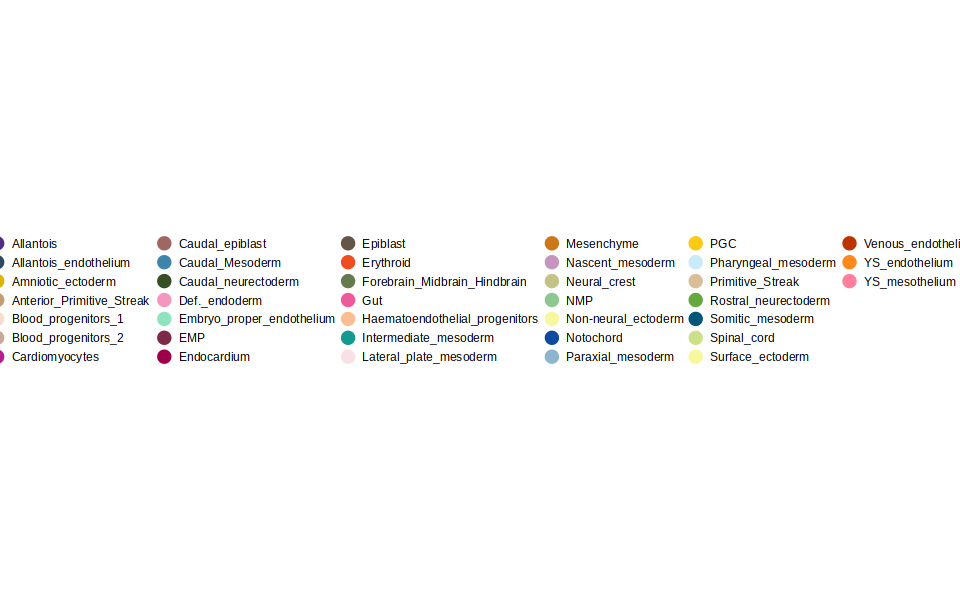

In [74]:
ggarrange(get_legend(p1))

In [75]:
ggsave(ggarrange(get_legend(p1)), 
       file = file.path(args$plot, 'gastrulation_legend.pdf'), 
        width = 190, 
        height = 40, 
       units = "mm")

In [117]:
celltype2germlayer = c(
    'Amniotic_ectoderm' = 'ectoderm', 
    'Surface_ectoderm' = 'ectoderm', 
    'Caudal_neurectoderm' = 'ectoderm',
    'Rostral_neurectoderm' = 'ectoderm', 
    'Spinal_cord' = 'ectoderm', 
    'NMP' = 'ectoderm', 
    'Forebrain_Midbrain_Hindbrain' = 'ectoderm', 
    'Neural_crest' = 'ectoderm', 

    'Notochord' = 'endoderm', 
    'Def._endoderm' = 'endoderm', 
    'Gut' = 'endoderm', 

    'PGC' = 'other', 
    'Caudal_epiblast' = 'other', 
    'Mixed' = 'other', 

    'Intermediate_mesoderm' = 'mesoderm', 
    'Nascent_mesoderm' = 'mesoderm',
    'Lateral_plate_mesoderm' = 'mesoderm', 
    'Allantois' = 'mesoderm', 
    'Somitic_mesoderm' = 'mesoderm', 
    'Caudal_Mesoderm' = 'mesoderm', 
    'Mesenchyme' = 'mesoderm', 
    'Pharyngeal_mesoderm' = 'mesoderm', 
    'Paraxial_mesoderm' = 'mesoderm', 
    'Cardiomyocytes' = 'mesoderm', 
    'YS_mesothelium' = 'mesoderm', 
    'Venous_endothelium' = 'mesoderm', 
    'Embryo_proper_endothelium' = 'mesoderm', 
    'Allantois_endothelium' = 'mesoderm', 
    'YS_endothelium' = 'mesoderm', 
    'Blood_progenitors_1' = 'mesoderm', 
    'Blood_progenitors_2' = 'mesoderm',
    'Erythroid' = 'mesoderm'
)

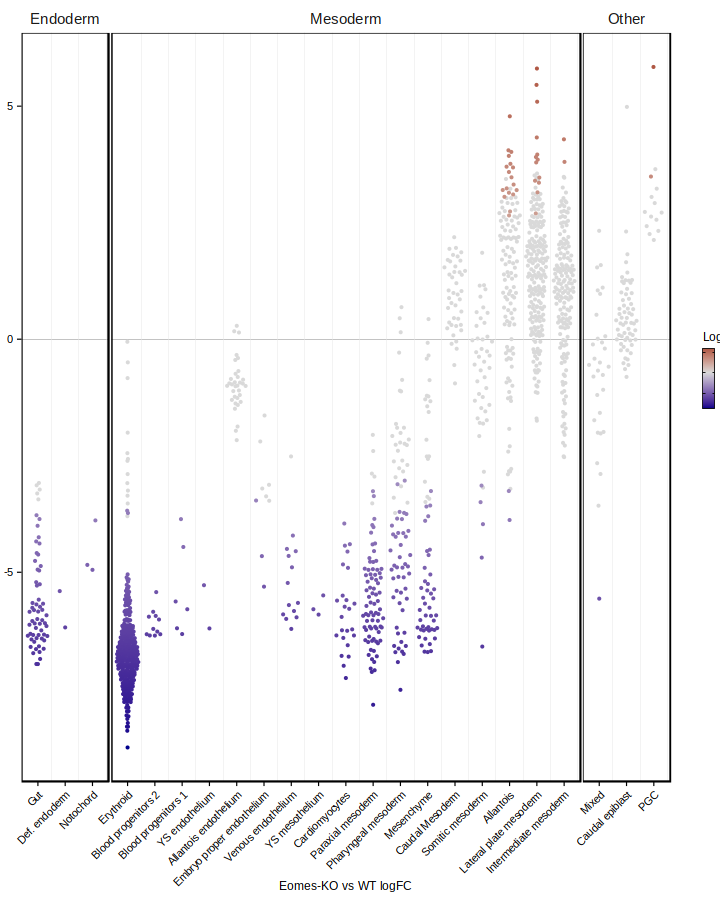

In [142]:
da_results.plot = as.data.table(da_results) %>% copy() %>%
    .[,color := ifelse(SpatialFDR < 0.05, logFC, 0)] %>% .[order(abs(color))] %>% 
    .[,germ_layer := str_to_title(celltype2germlayer[celltype_updated])] %>%
    .[, celltype_updated := factor( gsub('_', ' ', celltype_updated), levels =  rev(gsub('_', ' ', names(celltype2germlayer))))]

options(repr.plot.width = 6, repr.plot.height=7.5)
p_main = ggplot(da_results.plot[germ_layer != 'Ectoderm'], aes(celltype_updated, logFC, color=color)) + 
    geom_hline(yintercept = 0, color = 'grey50', linewidth = 0.1) +
    ggbeeswarm::geom_quasirandom(size = 0.1) + 
    geom_vline(xintercept=seq(1.5, 20, 1), color = 'grey90', linewidth = 0.1) + 
    scale_color_gradient2(low='darkblue', mid='grey85', high='darkred', name = 'LogFC') + 
    facet_grid(cols = vars(germ_layer), scales='free', space='free') + 
    guides(colour = guide_colourbar(
         barwidth = 0.5, barheight = 2.5,
        frame.colour = "black", 
        ticks.colour = "black"
    )) + 
    # ggtitle('Differential Abundance') + 
    xlab('Eomes-KO vs WT logFC') + 
    theme_bw() + 
    theme(axis.text = element_text(size=6, color='black'),
          axis.title.y = element_blank(),
          axis.title.x = element_text(size=7, color='black', vjust = 1.5),
          axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1), 
          axis.ticks = element_line(linewidth=0.25, color = 'black'),
          legend.text = element_text(size=6, color='black'),
          legend.title = element_text(size=7, color='black'),
          plot.title = element_text(size=8, color='black', hjust = 1, vjust = -1),
          panel.border = element_rect(color='black', linewidth=0.5),
          panel.spacing = unit(0.5, "mm"),
          legend.position = c(1.05, 0.55), # Position legend outside the plot (right and center vertically)
          legend.justification = c("left", "center"), # Justify legend to the center vertically and to the left horizontally
          legend.box.margin = margin(0, 0, 0, 0), # Adjust the margins around the legend box
          legend.margin = margin(0, 0, 0, 0), # Adjust the margins inside the legend box
          plot.margin = margin(3,30,3,3),
          panel.grid = element_blank(), 
          # legend.position='right',
          strip.background=element_blank(),
          strip.text.y = element_blank()) #_text(size=15, color='black', angle=0, hjust=0))
p_main
ggsave( file.path(args$plot, 'milo_quantification.pdf'), 
       plot = p_main, 
       width = 90, height = 50, units = "mm")

## Differential genes

In [79]:
args$outdir = paste0(io$basedir,"/results/rna/differential/celltype_updated")

In [83]:
# Functions
# Plotting function
gg_volcano_plot <- function(celltype_i='Allantois', top_genes=20, xlim=5, ylim=40, label_groups = NULL, y_axis = T) {
  to.plot = de.results[variable == celltype_i]
  negative_hits <- to.plot[sig==TRUE & logFC<0,gene]
  positive_hits <- to.plot[sig==TRUE & logFC>0,gene]
  all <- nrow(to.plot[!is.na(sig)])
  to.plot = to.plot[,logFC_plot:=ifelse(logFC<=-xlim, -xlim, ifelse(logFC>=xlim, xlim, logFC))] %>%
               .[,log10_padj_fdr:=ifelse(-log10(padj_fdr)>=ylim, ylim, -log10(padj_fdr))]
  
  to.plot <- to.plot[!is.na(logFC) & !is.na(padj_fdr)] %>% .[order(-abs(logFC))]
  to.plot <- to.plot[!is.na(logFC) & !is.na(padj_fdr)] %>% .[order(padj_fdr)]
  label_genes = c(head(to.plot[sig==T & logFC<=0, gene],n=top_genes), head(to.plot[sig==T & logFC>=0, gene],n=top_genes))
  
  p <- ggplot(to.plot, aes(x=logFC_plot, y=log10_padj_fdr)) +
    labs(x="Log fold change", y=expression(paste("-log"[10],"(FDR)"))) +
    ggrastr::rasterize(geom_point(aes(color=sig, size=sig), size = -0.3), dpi = 600) +
    # geom_hline(yintercept = -log10(opts$threshold_fdr), color="blue") +
    geom_segment(aes(x=0, xend=0, y=0, yend=ylim*1.16), color="orange", size=0.1) +
    scale_color_manual(values=c("black","red")) +
    scale_size_manual(values=c(0.5,1)) +
    scale_x_continuous(limits=c(-xlim,xlim)) +
    scale_y_continuous(limits=c(0,ylim*1.2), expand = c(0,0,0, 0)) +

    # annotate("text", x=0, y=ylim*1.1, size=6*0.35, label=sprintf("(%d)", all)) +
    annotate("text", x=-xlim*0.9, y=ylim*1.15, size=6*0.35, label=sprintf("%d (-)",length(negative_hits))) +
    annotate("text", x=xlim*0.9, y=ylim*1.15, size=6*0.35, label=sprintf("%d (+)",length(positive_hits))) +
    ggrepel::geom_text_repel(data=to.plot[gene %in% label_genes],
                                    aes(x=logFC_plot, y=log10_padj_fdr, label=gene), 
                                     max.overlaps=Inf, 
                                     box.padding = 0.1,
                                     segment.size = unit(0.1, 'mm'),
                                     bg.color='white', 
                                     bg.r = 0.1,
                                     size=6*0.35) +
    theme_classic() +
    theme(
      # axis.title = element_text(size=rel(1.0), color='black'),
      legend.position="none",
                panel.border = element_rect(color='black', linewidth=0.5, fill = NA),
        plot.title = element_text(size = 8, hjust = 0.5, face = 'plain'),
                axis.line = element_blank(),
        axis.ticks = element_line(linewidth=0.25, color = 'black'),
        axis.title.x = element_text(size = 7),
        axis.title.y = element_text(size = 7),
        # axis.text.x = element_text(angle=45, hjust=1, vjust=1, size=6, color = 'black'),
        plot.margin = margin(0,4,0,0),
        axis.text = element_text(size=6, color='black'),
        text = element_text(size=6),

    ) + 
    ggtitle(gsub('_', ' ', celltype_i))
    
    if(y_axis == F){
        p = p + theme(axis.text.y = element_blank(),
                      axis.title.y = element_blank())
    }
    
    
    if (length(label_groups)>0) {
        p <- p +
            annotate("text", x=-4, y=0, size=4, label=sprintf("Up in %s",label_groups[2])) +
            annotate("text", x=4, y=0, size=4, label=sprintf("Up in %s",label_groups[1]))
    }
  
  return(p)
}



In [84]:
de.results = fread(file.path(args$outdir, 'pseudoBulkSpecific.txt.gz'))

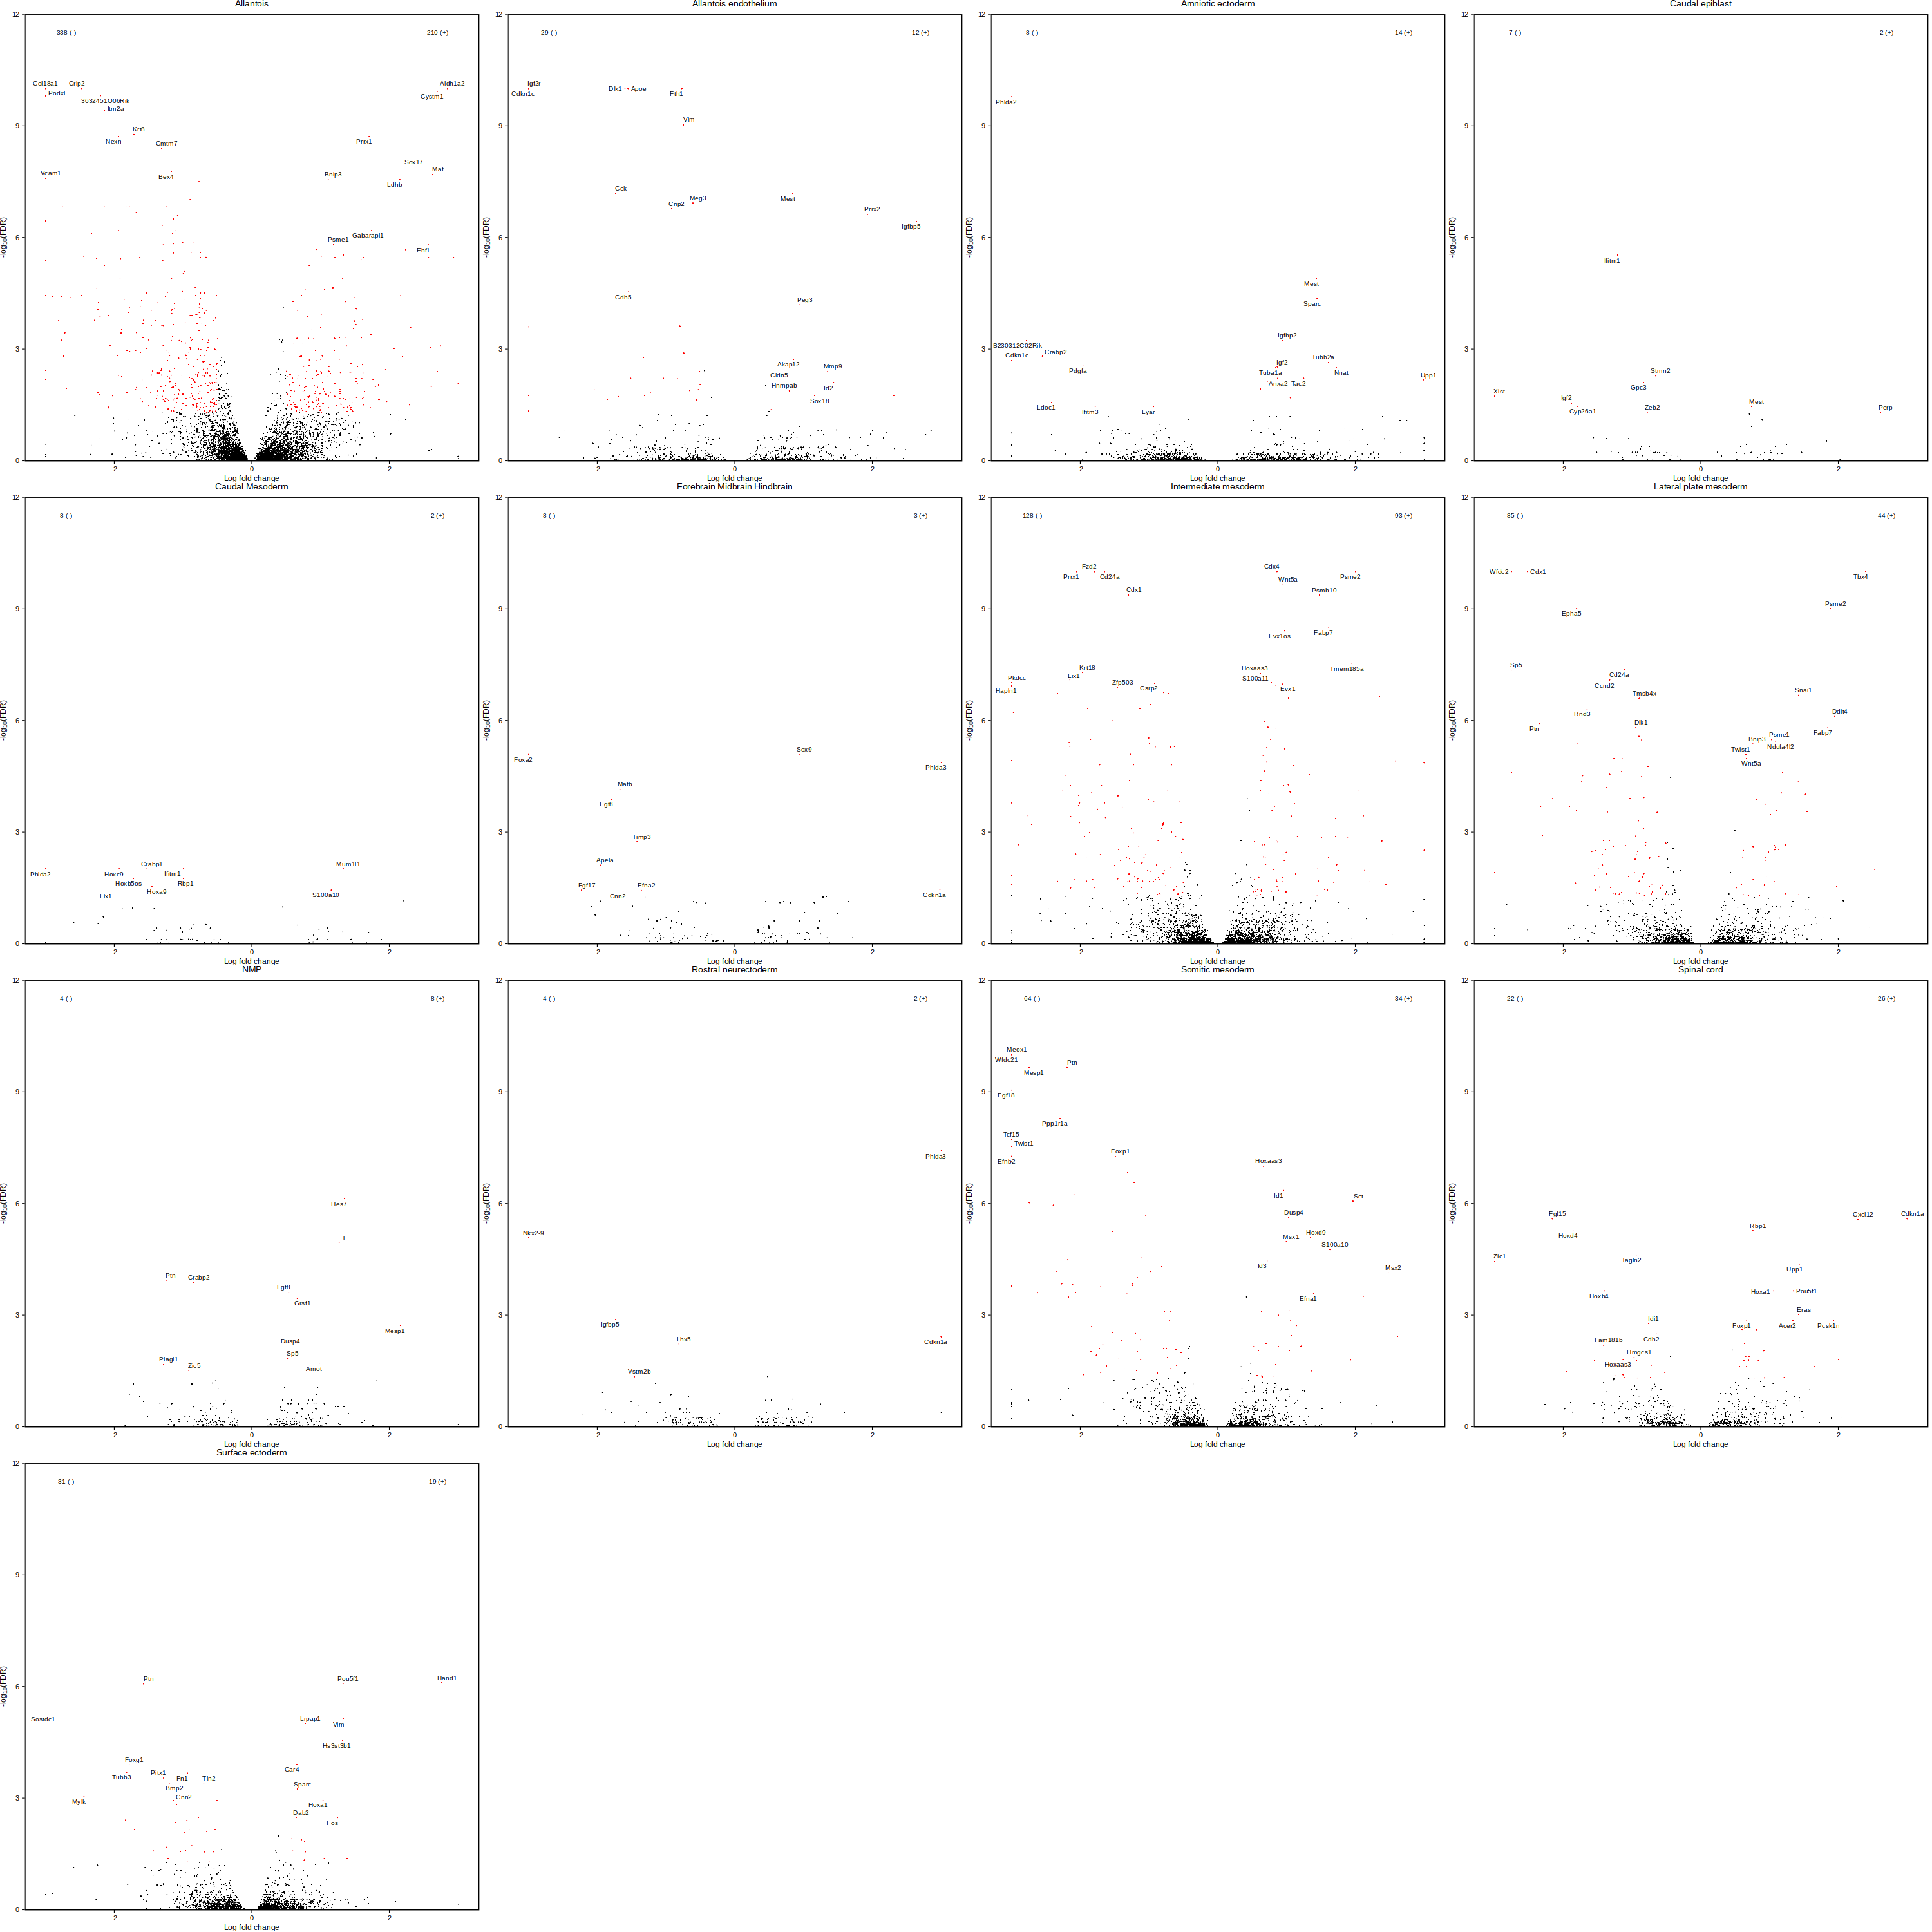

In [89]:
# Make plots
plots = lapply(unique(de.results$variable),gg_volcano_plot, ylim=10, xlim=3, top_genes=10)
combined_plot <- cowplot::plot_grid(plotlist = plots, ncol = 4)
options(repr.plot.width=25, repr.plot.height=25)
combined_plot

In [90]:
pdf(file = file.path(args$plot, 'DEGs_per_celltype.pdf'),   # The directory you want to save the file in
    width = 2, # The width of the plot in inches
    height = 2) # The height of the plot in inches
plots
dev.off()

[[1]]

[[2]]

[[3]]

[[4]]

[[5]]

[[6]]

[[7]]

[[8]]

[[9]]

[[10]]

[[11]]

[[12]]

[[13]]


png 
  2

In [148]:
    mapping = fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Mmusculus_genes_BioMart.07052024.txt')
head(mapping)

hgnc_symbol,ensembl_gene_id,entrezgene_id,external_gene_name
<chr>,<chr>,<int>,<chr>
SMIM46,ENSMUSG00000121579,NA,SMIM46
AKAP17A,ENSMUSG00000121606,118568424,AKAP17A
OR5BS1P,ENSMUSG00000108728,NA,OR5BS1P
,ENSMUSG00000064336,NA,mt-Tf
,ENSMUSG00000064337,NA,mt-Rnr1
,ENSMUSG00000064338,NA,mt-Tv


In [143]:
do_GO = function(genes, background=NULL){
    suppressPackageStartupMessages({
    library(biomaRt)
    library(limma)
    library(org.Mm.eg.db)
    })
    mapping = fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Mmusculus_genes_BioMart.07052024.txt')
    # Retrieve GO
    go = as.data.table(goana(mapping[match(genes, external_gene_name),entrezgene_id], species="Mm"), keep.rownames=T) %>% setnames('rn', 'GOALL') %>% 
        .[order(P.DE)] %>%
        .[,FDR := p.adjust(P.DE, method = 'fdr')] %>% 
        .[P.DE < 0.1] %>% 
        .[, enrichment := (length(genes)/N) / (N/32285)] %>%  # 32285 = nrow(rna.sce) # Enrichment should be depending on the number of genes in the term
        .[, enrichment := ifelse(enrichment > 100, 100, enrichment)] # set threshold for enrichment at 100
    # Add gene names to annotations
    GO_genes = AnnotationDbi::select(org.Mm.eg.db, keytype="GOALL", keys=go[, GOALL], columns='ENTREZID') %>% 
        as.data.table() %>% 
        .[, EVIDENCEALL := NULL] %>% 
        unique() %>% 
        merge(., mapping[,c('entrezgene_id', 'external_gene_name')] %>% 
                  .[, entrezgene_id := as.character(entrezgene_id)],
              by.x = 'ENTREZID', by.y = 'entrezgene_id')
    # Add genes into GO list
    go = mclapply(1:nrow(go), function(x){ # nrow(go)
        GO_genes_tmp = GO_genes[GOALL == go[x, GOALL], external_gene_name]
        genes_GO = intersect(GO_genes_tmp, genes)
        tmp = go[x,] %>% .[, `:=`(genes = paste0(genes_GO, collapse = ', '),
                                  N = length(intersect(background, GO_genes_tmp)))] %>%  # Ntot is only the number of genes in the GO that are also in the SCE object
        .[,enrichment := (DE/N)/(N/32285)] 
    }, mc.cores = 10) %>% rbindlist()
    
    options(repr.plot.width=10, repr.plot.height=4)
    plot = go %>% copy() %>%
           .[FDR < 0.05] %>% .[Ont == 'BP'] %>% .[N > 20 & N < 1000 & DE > 3 & enrichment > 3] %>% .[order(-enrichment)] %>% 
           # .[FDR < 0.05] %>% .[Ont == 'BP'] %>% .[N > 50 & N < 1000 & DE > 3 & enrichment > 5] %>% .[order(FDR)] %>% 
            .[,Term := factor(Term, levels = rev(Term))] %>% 
            .[, enrichment := ifelse(enrichment > 100, 100, enrichment)] %>% 
            head(10)
    p = ggplot(plot, 
           aes(enrichment, Term, color = -log10(FDR), fill = -log10(FDR), size = DE)) +  #, 
        geom_bar(stat = 'identity', aes(fill = -log10(FDR)), color = NA,  width = 0.05) +
        geom_point() + 
        geom_text(aes(x = max(plot$enrichment)/100, label = Term), vjust = -0.5, hjust = 0, color = 'black', size = 5 * 0.35) + 
        guides(fill = guide_colourbar(
             barwidth = 0.5, barheight = 2.5,
            frame.colour = "black", 
            ticks.colour = "black"
        )) + 
        scale_fill_gradientn(colors = c('white', 'blue', 'red'), limits = c(0, max(-log10(plot$FDR))), name = '-log10(FDR)') + 
        scale_color_gradientn(colors = c('white', 'blue', 'red'), limits = c(0, max(-log10(plot$FDR))), name = '-log10(FDR)') + 
        scale_x_continuous(limits = c(0, max(plot$enrichment)), expand = c(0,0,0,3)) + 
        theme_bw() + 
        theme(axis.text = element_text(size = 5, color = 'black'),
                axis.text.y = element_blank(), 
                axis.ticks.y = element_blank(),
                axis.title.x = element_text(size = 7),
                axis.title.y = element_blank(),
                panel.border = element_rect(color='black', linewidth=0.5, fill = NA),
                panel.background = element_rect(fill = 'white'),
                panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
                plot.margin = margin(0, 0, 0, 0),  # Adjust the margin around the plot
                # legend.margin = margin(0, 0, 0, 0),  # Adjust the margin inside the legend box
                # legend.box.margin = margin(0, 0, 0, 0),  # Adjust the margin outside the legend box
                legend.key.size  = unit(1, "mm"),
                legend.key = element_blank(),
                legend.position = 'right')
    return(list(go, p))
}

In [145]:
unique(de.results$sig)

[1]  TRUE FALSE

In [160]:
GO = do_GO(de.results[variable == 'Allantois' & sig == T & logFC > 0, gene], background = unique(de.results$gene))

'select()' returned 1:many mapping between keys and columns



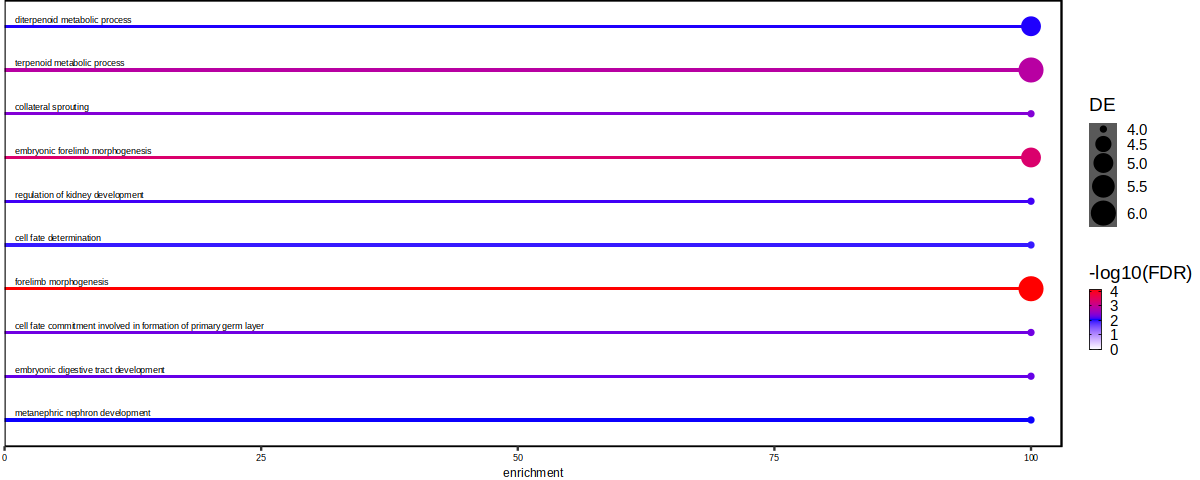

In [161]:
GO[[2]]

In [162]:
GO[[1]]

GOALL,Term,Ont,N,DE,P.DE,FDR,enrichment,genes
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
GO:0110165,cellular anatomical entity,CC,9508,189,1.014520e-24,2.320916e-20,0.06749697,"Phkb, Cep57l1, Airn, Dock9, Ankrd12, Pnrc1, Tpgs1, Fdps, Acat2, Etfb, Laptm4b, Aldoc, Nr2f2, Fabp7, Bnip3, Ccng2, Cirbp, Cited1, Cnih2, Crabp2, Asap1, Dkk1, Ebf1, Efna5, Eno3, Epha7, Celf2, Fzd1, Gata3, Gclc, Galk1, Gnal, Lancl1, H1f0, H2-Ab1, H2-K1, H3f3b, Hsd17b10, Hmox2, Hoxa5, Hoxa9, Hoxb3, Hoxb5, Elavl2, Id2, Igfbp5, Isl1, Jund, Kcnk2, Klf3, Aff3, Ldhb, Peg10, Maf, Matn2, Mea1, Meis1, Mrc2, mt-Co1, Mxi1, Nes, Nxn, Pafah1b3, Pbx1, Pdcd4, Prrx1, Eif2ak2, Cyth1, Psme1, Psme2, Dusp1, Ptprk, Aldh1a2, Rbp1, Reln, Rom1, Satb1, Scd1, Sfrp2, Selenow, Serf1, Sgk1, Six2, Sox17, Sox9, Dennd2a, Plekhh2, Casd1, Tbx3, Tet2, Lman2l, Timm17b, Zfp503, Tle4, Tspyl1, Unc5c, Taf6l, Plagl1, Tnrc18, Ccdc136, Ints6l, Gpatch8, Ets1, Aadat, Nt5e, Chd2, Tox3, Atr, Mllt6, Csad, Nbea, Robo2, Nrip1, Acot1, Zfp608, Abca8b, Ing4, Dhrs4, Ulk2, Pdlim4, Fndc3a, Tcp11l1, Fam169a, Negr1, Mast4, Hcn4, Akap17b, Kdm7a, Zfp395, Stum, Gm1673, Ndufa4l2, Maml3, Gm5617, Pgrmc1, Vamp5, Ramp2, Hmcn1, Hebp2, Txnip, Tspan3, Mocs1, Gabarapl1, Sall1, Eid1, Dact1, Fign, Fignl1, Zfand6, Prrg2, Ankrd37, Tmem176b, Tmem176a, Cystm1, Ifitm3, Osgep, Pyurf, Rbm24, Rnf128, Ssbp2, Trappc6a, Plxdc2, Narf, Etaa1, Ctc1, Kmt2e, Casz1, Fam162a, Cpm, Cotl1, Osgepl1, Atat1, Scpep1, Ddit4, Hoxb5os, Lin37, Grhpr, Gstk1, Mfap4, Ppp1r3g, Rbmxl2, Lpar4, Glis2, Trps1, Dtnbp1, Hmgn3, Cog8, Gorab, Rdh10"
GO:0005622,intracellular anatomical structure,CC,8779,165,3.038668e-24,3.475781e-20,0.06911855,"Phkb, Cep57l1, Airn, Ankrd12, Pnrc1, Tpgs1, Fdps, Acat2, Etfb, Laptm4b, Aldoc, Nr2f2, Fabp7, Bnip3, Ccng2, Cirbp, Cited1, Cnih2, Crabp2, Asap1, Ebf1, Eno3, Celf2, Gata3, Gclc, Galk1, Lancl1, H1f0, H2-Ab1, H2-K1, H3f3b, Hsd17b10, Hmox2, Hoxa5, Hoxa9, Hoxb3, Hoxb5, Id2, Isl1, Jund, Kcnk2, Klf3, Aff3, Ldhb, Peg10, Maf, Mea1, Meis1, mt-Co1, Mxi1, Nes, Nxn, Pafah1b3, Pbx1, Pdcd4, Prrx1, Eif2ak2, Cyth1, Psme1, Psme2, Dusp1, Ptprk, Aldh1a2, Rbp1, Reln, Satb1, Scd1, Selenow, Serf1, Sgk1, Six2, Sox17, Sox9, Dennd2a, Plekhh2, Casd1, Tbx3, Tet2, Lman2l, Timm17b, Zfp503, Tle4, Tspyl1, Taf6l, Plagl1, Tnrc18, Ccdc136, Ints6l, Gpatch8, Ets1, Aadat, Nt5e, Chd2, Tox3, Atr, Mllt6, Csad, Nbea, Nrip1, Acot1, Zfp608, Abca8b, Ing4, Dhrs4, Ulk2, Pdlim4, Fndc3a, Tcp11l1, Fam169a, Mast4, Hcn4, Akap17b, Kdm7a, Zfp395, Ndufa4l2, Maml3, Gm5617, Pgrmc1, Vamp5, Ramp2, Hmcn1, Hebp2, Txnip, Mocs1, Gabarapl1, Sall1, Eid1, Dact1, Fign, Fignl1, Zfand6, Ankrd37, Tmem176b, Ifitm3, Osgep, Pyurf, Rbm24, Rnf128, Ssbp2, Trappc6a, Narf, Etaa1, Ctc1, Kmt2e, Casz1, Fam162a, Cotl1, Osgepl1, Atat1, Scpep1, Ddit4, Hoxb5os, Lin37, Grhpr, Gstk1, Ppp1r3g, Rbmxl2, Lpar4, Glis2, Trps1, Dtnbp1, Hmgn3, Cog8, Gorab, Rdh10"
GO:0005488,binding,MF,7685,156,1.856899e-19,1.416009e-15,0.08527813,"Phkb, Cep57l1, Dock9, Tpgs1, Fdps, Etfb, Laptm4b, Aldoc, Nr2f2, Fabp7, Bnip3, Cirbp, Cited1, Crabp2, Asap1, Dkk1, Ebf1, Efna5, Eno3, Epha7, Celf2, Fzd1, Gata3, Gclc, Galk1, Gnal, Lancl1, H1f0, H2-Ab1, H2-K1, H3f3b, Hsd17b10, Hmox2, Hoxa5, Hoxa9, Hoxb3, Hoxb5, Elavl2, Id2, Igfbp5, Isl1, Jund, Kcnk2, Klf3, Aff3, Ldhb, Peg10, Maf, Matn2, Meis1, Mrc2, mt-Co1, Mxi1, Nes, Nxn, Pafah1b3, Pbx1, Pdcd4, Prrx1, Eif2ak2, Cyth1, Psme1, Psme2, Dusp1, Ptprk, Aldh1a2, Rbp1, Reln, Rom1, Satb1, Scd1, Sfrp2, Sgk1, Six2, Sox17, Sox9, Plekhh2, Casd1, Tbx3, Tet2, Lman2l, Zfp503, Tle4, Tspyl1, Unc5c, Wbp1, Taf6l, Plagl1, Tnrc18, Thnsl2, Rnf214, Gpatch8, Ets1, Aadat, Nt5e, Chd2, Tox3, Atr, Mllt6, Csad, Nbea, Robo2, Nrip1, Zfp608, Abca8b, Ing4, Dhrs4, Ulk2, Pdlim4, Mast4, Hcn4, Akap17b, Kdm7a, Zfp395, Pgrmc1, Ramp2, Hmcn1, Hebp2, Txnip, Mocs1, Gabarapl1, Sall1, Eid1, Dact1, Fign, Fignl1, Zfand6, Prrg2, Ankrd37, Tmem176b, Tmem176a, Osgep, Rbm24, Rnf128, Ssbp2, Narf, Mpnd, Ctc1, Kmt2e, Casz1, Cpm, Cotl1, Osgepl1, Ddit4, Hoxb5os, Grhpr, Gstk1, Mfap4, Ppp1r3g, Rbmxl2, Lpar4, Glis2, Trps1, Dtnbp1, Hmgn3, Gorab"
GO: